# Shot Frequency × Fatigue

Does fatigue change how often a player shoots?

**Response**: all shot attempts per shift (count), with `log(ice_min)` as
an offset so we're modeling the *rate* (shots per minute on ice), not the raw count.

**Shot attempts** = `Event in ['Shot', 'Goal']` — all releases, including blocked shots.
Blocked shots represent a decision to shoot; the player pulled the trigger regardless
of what happened next. Including them measures shooting intent, not just outcome.

**Key models**:
1. Poisson GLM with log link + offset — natural for count rates
2. Negative binomial — checks if Poisson is overdispersed (common with shot counts)
3. Within-player slope analysis — avoids between-player confound (some players
   just shoot more than others regardless of fatigue)


In [2]:
import sys, warnings
sys.path.insert(0, str(__import__('pathlib').Path('.').resolve()))
sys.path.insert(0, str(__import__('pathlib').Path('..').resolve()))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
import scipy.stats as sps

from build_shift_df import build_shift_df, POS_COLORS
from utils import load_events

OUTPUT_DIR = __import__('pathlib').Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

events   = load_events('../data/events.parquet')
shift_df = build_shift_df('../data')  # use cache if fresh

# Derived convenience columns
# shift_df['is_forward']         = (shift_df['position'] != 'D').astype(int)\n
shift_df['is_first_int']       = shift_df['is_first_shift'].astype(int)
shift_df['rest_time_min']      = shift_df['rest_time_s'] / 60.0
shift_df['shift_duration_min'] = shift_df['shift_duration_s'] / 60.0

print(f'Events  : {len(events):,}')
print(f'shift_df: {len(shift_df):,} shifts')

Loading cached shift_df from /Users/joeharter/repos/bdc-2026/stamina_models/shift_df.parquet
Events  : 19,200
shift_df: 6,218 shifts


## Step 1 — Count shot attempts per shift

In [3]:
# All shot attempts: Shot or Goal (blocked, on net, missed, fan — everything)
shot_events = events[
    events['Event'].isin(['Shot', 'Goal'])
].copy()
shot_events['Player_Id']           = shot_events['Player_Id'].astype(str)
shot_events['elapsed_in_period_s'] = shot_events['Elapsed_s'] - (shot_events['Period_int'] - 1) * 1200

print(f"All shot attempts: {len(shot_events):,}")
print(f"  On Net  : {(shot_events['Detail_2'] == 'On Net').sum()}")
print(f"  Goals   : {(shot_events['Event'] == 'Goal').sum()}")
print(f"  Missed  : {(shot_events['Detail_2'] == 'Missed').sum()}")
print(f"  Blocked : {(shot_events['Detail_2'] == 'Blocked').sum()}")
print(f"  Fan     : {(shot_events['Detail_1'] == 'Fan').sum()}")

# Count shots per (Game, Period_int, Player_Id) per shift window
# Join shots to shift_df by checking which shift was active at event time
shift_lookup = shift_df[[
    'Game', 'Period_int', 'Player_Id', 'Team',
    'shift_start_s', 'shift_end_s',
]].copy()
shift_lookup['Player_Id'] = shift_lookup['Player_Id'].astype(str)

# Include Team in merge keys so the column isn't duplicated with suffixes
merged = shot_events.merge(
    shift_lookup,
    on=['Game', 'Period_int', 'Player_Id', 'Team'],
    how='inner',
)
in_shift = (
    (merged['elapsed_in_period_s'] >= merged['shift_start_s']) &
    (merged['elapsed_in_period_s'] <= merged['shift_end_s'] + 2)
)
shots_in_shifts = merged[in_shift].copy()

# Count shots per shift (one row per shot → group and count)
shot_counts = (
    shots_in_shifts
    .groupby(['Game', 'Period_int', 'Player_Id', 'Team', 'shift_start_s', 'shift_end_s'])
    .size()
    .reset_index(name='shot_count')
)

# Left-join back to shift_df so shifts with 0 shots are included
model_df = shift_df.merge(
    shot_counts,
    on=['Game', 'Period_int', 'Player_Id', 'Team', 'shift_start_s', 'shift_end_s'],
    how='left',
)
model_df['shot_count'] = model_df['shot_count'].fillna(0).astype(int)
model_df['shots_per_min'] = model_df['shot_count'] / model_df['ice_min']
model_df['log_ice_min']   = np.log(model_df['ice_min'])

print(f"\nShifts total         : {len(model_df):,}")
print(f"Shifts with 0 shots  : {(model_df['shot_count'] == 0).sum():,}  ({100*(model_df['shot_count']==0).mean():.1f}%)")
print(f"Shifts with ≥1 shot  : {(model_df['shot_count'] >= 1).sum():,}")
print(f"Max shots in a shift : {model_df['shot_count'].max()}")
print(f"\nShots per minute (mean): {model_df['shots_per_min'].mean():.4f}")
print(f"Shots per minute by position:")
print(model_df.groupby('position')['shots_per_min'].describe().round(4))


All shot attempts: 1,190
  On Net  : 566
  Goals   : 58
  Missed  : 334
  Blocked : 290
  Fan     : 32

Shifts total         : 6,218
Shifts with 0 shots  : 5,327  (85.7%)
Shifts with ≥1 shot  : 891
Max shots in a shift : 5

Shots per minute (mean): 0.2888
Shots per minute by position:
           count    mean     std  min  25%  50%  75%      max
position                                                     
C          791.0  0.2420  0.6954  0.0  0.0  0.0  0.0   4.9496
D         3673.0  0.2769  0.8028  0.0  0.0  0.0  0.0   9.4987
F         1754.0  0.3350  0.9475  0.0  0.0  0.0  0.0  11.0769


## Step 2 — EDA: shot count distribution and rate by fatigue

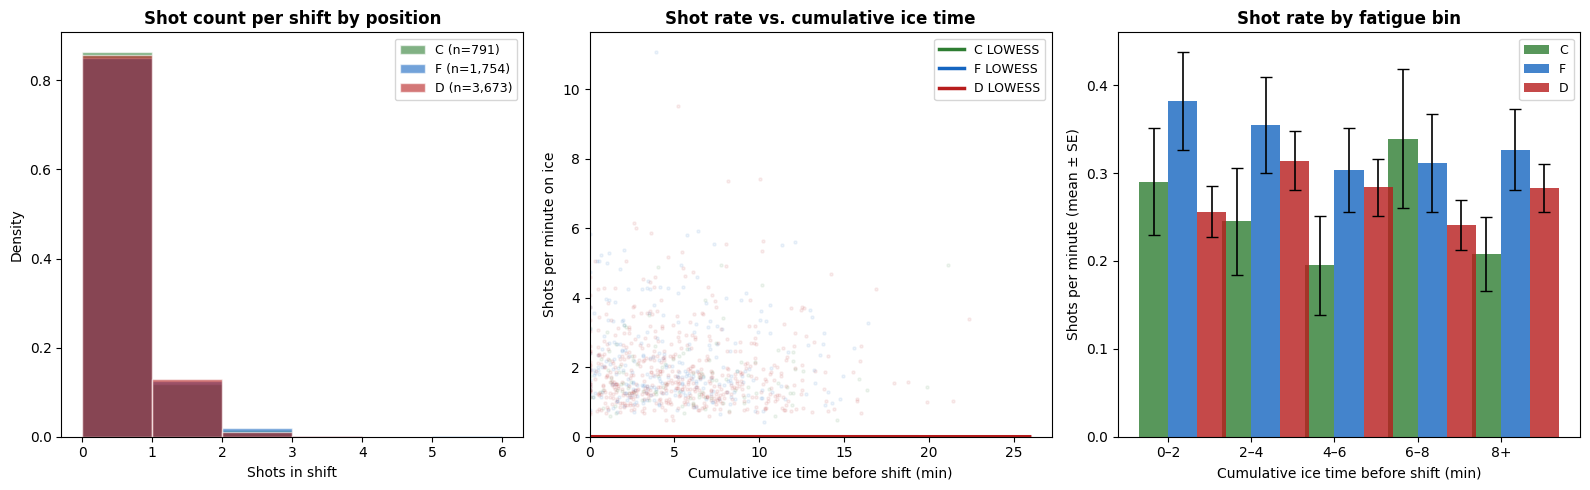

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: shot count histogram by position
ax = axes[0]
for pos, col in POS_COLORS.items():
    vals = model_df.loc[model_df['position'] == pos, 'shot_count']
    ax.hist(vals, bins=range(0, vals.max() + 2), alpha=0.6, color=col,
            label=f'{pos} (n={len(vals):,})', density=True, edgecolor='white')
ax.set_xlabel('Shots in shift')
ax.set_ylabel('Density')
ax.set_title('Shot count per shift by position', fontweight='bold')
ax.legend(fontsize=9)

# Panel 2: shots per minute vs cumulative ice time, LOWESS
ax = axes[1]
for pos, col in POS_COLORS.items():
    s = model_df[model_df['position'] == pos].dropna(subset=['cumulative_ice_min_before', 'shots_per_min'])
    ax.scatter(s['cumulative_ice_min_before'], s['shots_per_min'],
               alpha=0.07, s=5, color=col, rasterized=True)
    if len(s) >= 30:
        lw_out = lowess(s['shots_per_min'].values, s['cumulative_ice_min_before'].values,
                        frac=0.5, return_sorted=True)
        ax.plot(lw_out[:, 0], lw_out[:, 1], color=col, lw=2.5, label=f'{pos} LOWESS')
ax.set_xlabel('Cumulative ice time before shift (min)')
ax.set_ylabel('Shots per minute on ice')
ax.set_title('Shot rate vs. cumulative ice time', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

# Panel 3: shot rate by fatigue bin (mean ± SE)
ax = axes[2]
model_df['cum_ice_bin'] = pd.cut(
    model_df['cumulative_ice_min_before'],
    bins=[0, 2, 4, 6, 8, 100],
    labels=['0–2', '2–4', '4–6', '6–8', '8+'],
)
x_labels = ['0–2', '2–4', '4–6', '6–8', '8+']
x_pos = np.arange(len(x_labels))
width = 0.35
for i, (pos, col) in enumerate(POS_COLORS.items()):
    s = model_df[model_df['position'] == pos]
    bin_stats = s.groupby('cum_ice_bin', observed=True)['shots_per_min'].agg(['mean', 'sem'])
    offset = (i - 0.5) * width
    ax.bar(x_pos + offset, bin_stats['mean'], width=width, color=col, alpha=0.8,
           label=pos, yerr=bin_stats['sem'], capsize=4, error_kw={'lw': 1.2})
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Cumulative ice time before shift (min)')
ax.set_ylabel('Shots per minute (mean ± SE)')
ax.set_title('Shot rate by fatigue bin', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_shot_freq_eda.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3 — Poisson GLM with offset

Modeling `shot_count` with `log(ice_min)` as offset is equivalent to modeling
shots-per-minute but keeps the count likelihood correct. The exponentiated coefficients
are **rate ratios** — e.g. OR=0.95 means 5% fewer shots per minute.

In [14]:

glm_df = model_df.dropna(subset=[
    'shot_count', 'log_ice_min', 'cumulative_ice_min_before',
    'rest_time_min', 'position', 'score_diff', 'shift_duration_min',
]).copy()
glm_df['team_player'] = glm_df['Team'] + '_' + glm_df['Player_Id']

formula = (
    'shot_count ~ cumulative_ice_min_before + rest_time_min + shift_duration_min + '
    "+ C(position, Treatment('D')) + score_diff + shift_duration_min + C(Period_int)"
)

poisson = smf.glm(
    formula,
    data=glm_df,
    family=sm.families.Poisson(),
    offset=glm_df['log_ice_min'],
).fit()

print(poisson.summary2())

# Rate ratios + CI
rr_terms = [
    'cumulative_ice_min_before', 'rest_time_min',
    "C(position, Treatment('D'))[T.C]", "C(position, Treatment('D'))[T.F]",
    'score_diff', 'shift_duration_min',
]
params = poisson.params
conf   = poisson.conf_int()
pvals  = poisson.pvalues
rr_rows = []
for t in rr_terms:
    if t in params.index:
        rr_rows.append({
            'Predictor': t,
            'Rate Ratio': np.exp(params[t]),
            'CI_lo': np.exp(conf.loc[t, 0]),
            'CI_hi': np.exp(conf.loc[t, 1]),
            'p': pvals[t],
        })
rr_df = pd.DataFrame(rr_rows).set_index('Predictor')
rr_df['sig'] = rr_df['p'].apply(lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')))
print('\nRate Ratios (Poisson):')
print(rr_df.round(4).to_string())


                        Results: Generalized linear model
Model:                     GLM                   AIC:                 5730.2667  
Link Function:             Log                   BIC:                 -50372.0558
Dependent Variable:        shot_count            Log-Likelihood:      -2856.1    
Date:                      2026-03-15 18:30      LL-Null:             -2865.9    
No. Observations:          6218                  Deviance:            3864.8     
Df Model:                  8                     Pearson chi2:        6.97e+03   
Df Residuals:              6209                  Scale:               1.0000     
Method:                    IRLS                                                  
---------------------------------------------------------------------------------
                                  Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
---------------------------------------------------------------------------------
Intercept                        -1.4950

## Step 4 — Overdispersion check → Negative Binomial

Poisson assumes variance = mean. Shot counts are often overdispersed (variance > mean)
because some shifts are just naturally high-event. If overdispersed, Poisson SEs are
too small and p-values too optimistic — negative binomial corrects this.

In [9]:
# Overdispersion: compare Pearson χ² / df to 1.0
pearson_chi2 = poisson.pearson_chi2
df_resid     = poisson.df_resid
dispersion   = pearson_chi2 / df_resid
print(f"Poisson Pearson χ²/df = {dispersion:.3f}")
if dispersion > 1.5:
    print("→ Overdispersed — fitting Negative Binomial")
else:
    print("→ Reasonably well-specified — Poisson is adequate")
print()

nb = smf.glm(
    formula,
    data=glm_df,
    family=sm.families.NegativeBinomial(),
    offset=glm_df['log_ice_min'],
).fit()

print(nb.summary2())

# Side-by-side rate ratio comparison
nb_rows = []
for t in rr_terms:
    if t in nb.params.index:
        nb_rows.append({
            'Predictor': t,
            'RR (Poisson)': np.exp(poisson.params[t]),
            'p (Poisson)':  poisson.pvalues[t],
            'RR (NegBin)':  np.exp(nb.params[t]),
            'p (NegBin)':   nb.pvalues[t],
        })
comp_df = pd.DataFrame(nb_rows).set_index('Predictor')
for col in ['RR (Poisson)', 'RR (NegBin)']:
    comp_df[col] = comp_df[col].round(4)
for col in ['p (Poisson)', 'p (NegBin)']:
    comp_df[col] = comp_df[col].round(4)
print('\nPoisson vs Negative Binomial — rate ratios for fatigue predictors:')
print(comp_df.to_string())

Poisson Pearson χ²/df = 1.117
→ Reasonably well-specified — Poisson is adequate

                    Results: Generalized linear model
Model:                  GLM                 AIC:               5731.7138  
Link Function:          Log                 BIC:               -51112.4022
Dependent Variable:     shot_count          Log-Likelihood:    -2857.9    
Date:                   2026-03-14 22:33    LL-Null:           -2866.0    
No. Observations:       6218                Deviance:          3133.2     
Df Model:               7                   Pearson chi2:      5.98e+03   
Df Residuals:           6210                Scale:             1.0000     
Method:                 IRLS                                              
--------------------------------------------------------------------------
                           Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
--------------------------------------------------------------------------
Intercept                 -1.5103   0.12

## Step 4b — GEE: Poisson with cluster-robust SEs

Poisson and NegBin GLMs assume every shift is independent. A player's shifts within
a game are correlated — they share the same shooting tendency. GEE accounts for this
by specifying an **exchangeable** within-player correlation structure and producing
**cluster-robust (sandwich) standard errors**.

This mirrors the GEE approach used in nb03 for acceleration counts and is the most
principled way to handle the repeated-measures structure.


In [17]:
from statsmodels.genmod.cov_struct import Exchangeable

# smf.gee ignores Treatment() — set D as reference via ordered Categorical
gee_df = glm_df.sort_values(['team_player', 'Period_int', 'shift_start_s']).reset_index(drop=True)
gee_df['position'] = pd.Categorical(gee_df['position'], categories=['D', 'C', 'F'])

# Use plain C(position) — D is first category so it becomes the reference
gee_formula = (
    'shot_count ~ cumulative_ice_min_before + rest_time_min + shift_duration_min '
    '+ C(position) + score_diff + C(Period_int)'
)

gee = smf.gee(
    gee_formula,
    groups='team_player',
    data=gee_df,
    family=sm.families.Poisson(),
    cov_struct=Exchangeable(),
    offset=gee_df['log_ice_min'],
).fit()

print(gee.summary())

within_corr = gee.cov_struct.dep_params
print(f'\nEstimated within-player correlation (exchangeable α) : {within_corr:.4f}')
print(f'  → {100*within_corr:.1f}% correlation between any two shifts from the same player.')
print(f'   (If α is high, GLM SEs were anti-conservative; GEE SEs are trustworthy.)')

qic_vals = gee.qic()
print(f'\nGEE QIC         : {qic_vals[0]:.1f}')
print(f'Poisson AIC     : {poisson.aic:.1f}')
print(f'NegBin  AIC     : {nb.aic:.1f}')

# GEE term names — D is reference, so dummies are T.C and T.F
gee_rr_terms = [
    'cumulative_ice_min_before', 'rest_time_min', 'shift_duration_min',
    'C(position)[T.C]', 'C(position)[T.F]',
    'score_diff',
]

# Map from GEE term names → GLM term names (for Poisson/NegBin lookup)
gee_to_glm = {
    'C(position)[T.C]': "C(position, Treatment('D'))[T.C]",
    'C(position)[T.F]': "C(position, Treatment('D'))[T.F]",
}

print('\nIncident Rate Ratios (GEE, cluster-robust SEs):')
gee_params = gee.params
gee_conf   = gee.conf_int()
gee_pvals  = gee.pvalues
irr_rows = []
for t in gee_rr_terms:
    if t in gee_params.index:
        irr_rows.append({
            'Predictor': t,
            'IRR'      : np.exp(gee_params[t]),
            'CI_lo'    : np.exp(gee_conf.loc[t, 0]),
            'CI_hi'    : np.exp(gee_conf.loc[t, 1]),
            'p'        : gee_pvals[t],
        })
irr_df = pd.DataFrame(irr_rows).set_index('Predictor')
irr_df['sig'] = irr_df['p'].apply(lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.')))
print(irr_df.round(4).to_string())

# Side-by-side comparison using correct term names per model
print('\nRate Ratio comparison — Poisson / NegBin / GEE:')
cmp_rows = []
for gee_t in gee_rr_terms:
    if gee_t not in gee_params.index:
        continue
    glm_t = gee_to_glm.get(gee_t, gee_t)  # same name for non-position terms
    cmp_rows.append({
        'Predictor'    : gee_t,
        'RR (Poisson)' : np.exp(poisson.params.get(glm_t, float('nan'))),
        'p (Poisson)'  : poisson.pvalues.get(glm_t, float('nan')),
        'RR (NegBin)'  : np.exp(nb.params.get(glm_t, float('nan'))),
        'p (NegBin)'   : nb.pvalues.get(glm_t, float('nan')),
        'IRR (GEE)'    : np.exp(gee_params[gee_t]),
        'p (GEE)'      : gee_pvals[gee_t],
    })
cmp_df = pd.DataFrame(cmp_rows).set_index('Predictor')
for col in ['RR (Poisson)', 'RR (NegBin)', 'IRR (GEE)']:
    cmp_df[col] = cmp_df[col].round(4)
for col in ['p (Poisson)', 'p (NegBin)', 'p (GEE)']:
    cmp_df[col] = cmp_df[col].round(4)
print(cmp_df.to_string())


                               GEE Regression Results                              
Dep. Variable:                  shot_count   No. Observations:                 6218
Model:                                 GEE   No. clusters:                      234
Method:                        Generalized   Min. cluster size:                   2
                      Estimating Equations   Max. cluster size:                 111
Family:                            Poisson   Mean cluster size:                26.6
Dependence structure:         Exchangeable   Num. iterations:                     7
Date:                     Sun, 15 Mar 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         18:41:20
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -1.5104      0.124    -12.2

## Step 5 — Shot rate over the course of the game

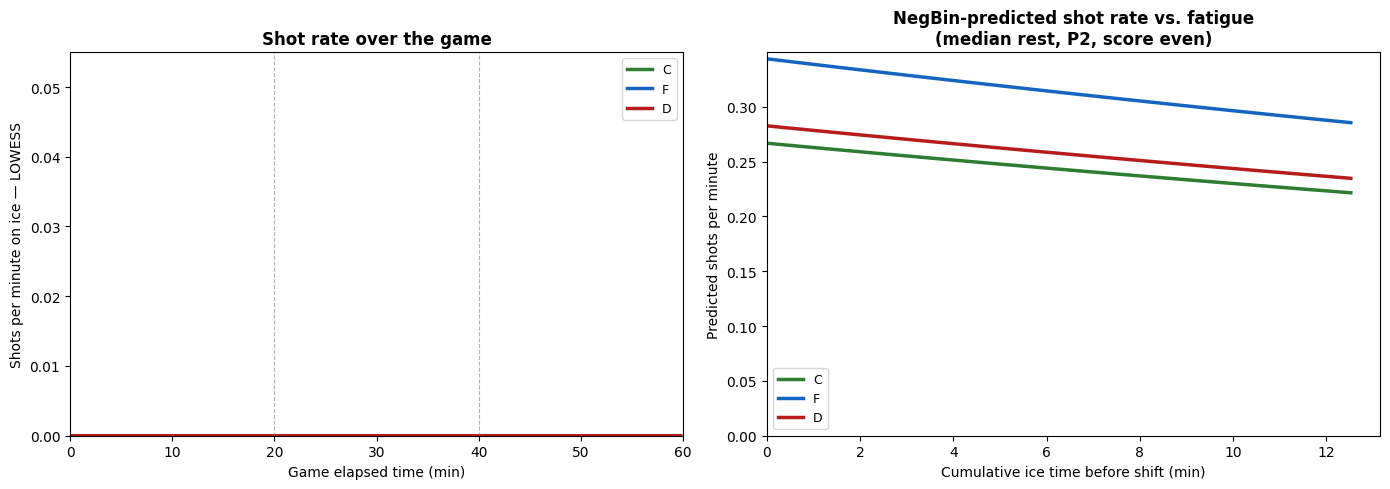

In [ ]:

model_df['game_elapsed_min'] = (
    (model_df['Period_int'] - 1) * 20 +
    model_df['shift_start_s'] / 60.0
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: shots per minute vs game elapsed time, LOWESS
ax = axes[0]
for pos, col in POS_COLORS.items():
    s = model_df[model_df['position'] == pos].dropna(subset=['game_elapsed_min', 'shots_per_min'])
    if len(s) >= 30:
        lw_out = lowess(s['shots_per_min'].values, s['game_elapsed_min'].values,
                        frac=0.4, return_sorted=True)
        ax.plot(lw_out[:, 0], lw_out[:, 1], color=col, lw=2.5, label=pos)
for xv in [20, 40]:
    ax.axvline(xv, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel('Game elapsed time (min)')
ax.set_ylabel('Shots per minute on ice — LOWESS')
ax.set_title('Shot rate over the game', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 60)
ax.set_ylim(bottom=0)

# Panel 2: model-predicted shot rate vs cumulative ice time
ax = axes[1]
ice_range = np.linspace(0, glm_df['cumulative_ice_min_before'].quantile(0.95), 100)
ref_ice_min = glm_df['ice_min'].median()
for pos, col in POS_COLORS.items():
    pred_df = pd.DataFrame({
        'cumulative_ice_min_before': ice_range,
        'rest_time_min'            : glm_df['rest_time_min'].median(),
        'position'                 : pos,
        'score_diff'               : 0,
        'Period_int'               : 2,
        'shift_duration_min'       : glm_df['shift_duration_min'].median(),
        'log_ice_min'              : np.log(ref_ice_min),
    })
    pred_df['Period_int'] = pred_df['Period_int'].astype(int)
    # Predicted count ÷ ref_ice_min = predicted rate
    pred_count = nb.predict(pred_df, offset=pred_df['log_ice_min'])
    ax.plot(ice_range, pred_count / ref_ice_min, color=col, lw=2.5, label=pos)

ax.set_xlabel('Cumulative ice time before shift (min)')
ax.set_ylabel('Predicted shots per minute')
ax.set_title('NegBin-predicted shot rate vs. fatigue\n(median rest, P2, score even)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_shot_rate_vs_fatigue.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 6 — Within-player: does a player's own shot rate change with fatigue?

Players differ in how trigger-happy they are — some shoot every chance, others rarely.
Between-player differences would confound the GLM if high-volume shooters also happen
to have more cumulative ice time. Within-player slopes isolate the fatigue signal.

Players with ≥5 shifts: 233
Shifts included       : 6,216


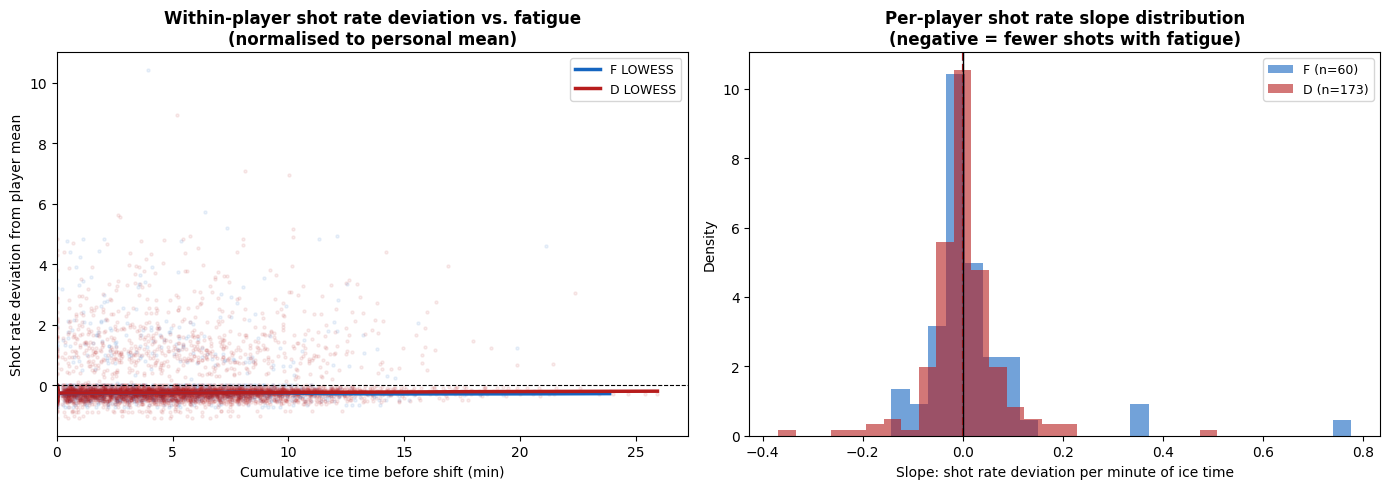


F: median slope = +0.00000 shots/min per min of ice  t = 1.39  p = 0.1712  (45% show decline)
D: median slope = +0.00000 shots/min per min of ice  t = 0.33  p = 0.7406  (46% show decline)


In [ ]:

wp = model_df.copy()
wp['team_player'] = wp['Team'] + '_' + wp['Player_Id']

# Normalize each player to their own mean shot rate
player_mean = wp.groupby('team_player')['shots_per_min'].mean().rename('player_mean_rate')
player_n    = wp.groupby('team_player')['shots_per_min'].count().rename('player_n_shifts')
wp = wp.join(player_mean, on='team_player').join(player_n, on='team_player')
wp = wp[wp['player_n_shifts'] >= 5].copy()   # need ≥5 shifts for a meaningful slope
wp['rate_dev'] = wp['shots_per_min'] - wp['player_mean_rate']

print(f"Players with ≥5 shifts: {wp['team_player'].nunique():,}")
print(f"Shifts included       : {len(wp):,}")

# Per-player OLS slope: rate_dev ~ cumulative_ice_min_before
from scipy.stats import linregress
slopes = []
for tp, grp in wp.groupby('team_player'):
    if len(grp) < 5:
        continue
    sl = linregress(grp['cumulative_ice_min_before'].values, grp['rate_dev'].values).slope
    slopes.append({'slope': sl, 'position': grp['position'].iloc[0]})
slopes_df = pd.DataFrame(slopes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: within-player shot rate deviation vs cumulative ice time, LOWESS
ax = axes[0]
for pos, col in POS_COLORS.items():
    s = wp[wp['position'] == pos]
    ax.scatter(s['cumulative_ice_min_before'], s['rate_dev'],
               alpha=0.08, s=5, color=col, rasterized=True)
    if len(s) >= 30:
        lw_out = lowess(s['rate_dev'].values, s['cumulative_ice_min_before'].values,
                        frac=0.5, return_sorted=True)
        ax.plot(lw_out[:, 0], lw_out[:, 1], color=col, lw=2.5, label=f'{pos} LOWESS')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Cumulative ice time before shift (min)')
ax.set_ylabel('Shot rate deviation from player mean')
ax.set_title('Within-player shot rate deviation vs. fatigue\n(normalised to personal mean)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(left=0)

# Panel 2: per-player slope distribution
ax = axes[1]
for pos, col in POS_COLORS.items():
    s = slopes_df[slopes_df['position'] == pos]['slope'].dropna()
    ax.hist(s, bins=25, alpha=0.6, color=col, label=f'{pos} (n={len(s)})',
            density=True, edgecolor='none')
    ax.axvline(s.median(), color=col, lw=1.5, ls='--')
ax.axvline(0, color='k', lw=1)
ax.set_xlabel('Slope: shot rate deviation per minute of ice time')
ax.set_ylabel('Density')
ax.set_title('Per-player shot rate slope distribution\n(negative = fewer shots with fatigue)', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_shot_rate_within_player.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats + t-test vs 0
import scipy.stats as sps
print()
for pos in ['C', 'F', 'D']:
    s = slopes_df[slopes_df['position'] == pos]['slope'].dropna()
    if len(s) < 2:
        print(f"{pos}: too few players (n={len(s)}) for t-test")
        continue
    t, p = sps.ttest_1samp(s, 0)
    pct_neg = (s < 0).mean()
    print(f"{pos}: median slope = {s.median():+.5f} shots/min per min of ice  "
          f"t = {t:.2f}  p = {p:.4f}  ({100*pct_neg:.0f}% show decline)")


## Step 7 — LMM: within-player shot rate controlling for all confounders

Linear mixed model on `shots_per_min` with player random intercepts. This is
approximate (shot rate is bounded at 0 and not truly Gaussian) but gives cleaner
inference on the fixed effects than a GLMM, and works well in practice when counts
are not heavily zero-inflated.

In [ ]:

lmm_df = model_df.dropna(subset=[
    'shots_per_min', 'cumulative_ice_min_before', 'rest_time_min',
    'position', 'score_diff', 'shift_duration_min',
]).copy()
lmm_df['team_player'] = lmm_df['Team'] + '_' + lmm_df['Player_Id']

lmm_formula = (
    'shots_per_min ~ cumulative_ice_min_before + rest_time_min '
    "+ C(position, Treatment('D')) + score_diff + shift_duration_min + C(Period_int)"
)
lmm = smf.mixedlm(lmm_formula, data=lmm_df, groups=lmm_df['team_player']).fit(reml=True)
print(lmm.summary())

player_var   = lmm.cov_re.iloc[0, 0]
residual_var = lmm.scale
icc = player_var / (player_var + residual_var)
print(f'\nICC (between-player variance fraction): {icc:.3f}')
print(f'  → {100*icc:.1f}% of shot rate variance is between-player shooting tendency')

coef = lmm.params.get('cumulative_ice_min_before', float('nan'))
p    = lmm.pvalues.get('cumulative_ice_min_before', float('nan'))
print(f'\ncumulative_ice_min_before: coef = {coef:+.5f} shots/min per min of ice  p = {p:.4f}')
if p < 0.05:
    direction = 'FEWER' if coef < 0 else 'MORE'
    print(f'→ Significant: fatigued players take {direction} shots per minute.')
else:
    print('→ No significant relationship between cumulative ice time and shot rate (p ≥ 0.05).')


               Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    shots_per_min
No. Observations:    6218       Method:                REML         
No. Groups:          234        Scale:                 0.6896       
Min. group size:     2          Log-Likelihood:        -7710.7376   
Max. group size:     111        Converged:             Yes          
Mean group size:     26.6                                           
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.201    0.039  5.164 0.000  0.125  0.277
C(position)[T.D]           0.041    0.036  1.137 0.255 -0.029  0.110
C(position)[T.F]           0.101    0.039  2.579 0.010  0.024  0.178
C(Period_int)[T.2]         0.023    0.032  0.715 0.475 -0.039  0.085
C(Period_int)[T.3]         0.042    0.048  0.875 0